# Customer Churn Prediction System

## Model Training

In this notebook, we will train multiple machine learning models, evaluate their performance, compare their results, and select the best-performing model for deployment.

In [30]:
# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns 

# Model Selection
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Model Saving
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load Processed Dataset

Load the cleaned dataset prepared during preprocessing.

In [31]:
df = pd.read_csv("../data/processed/processed_telco.csv")

df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label
0,1,78,0,1,0,0,0,0,0,554,...,1,0,39.65,39.65,0.00,20,0.00,59.65,3,1
1,0,74,0,1,1,1,1,0,0,554,...,1,1,80.65,633.30,0.00,0,390.80,1024.10,3,1
2,1,71,0,1,0,1,3,0,0,554,...,1,0,95.45,1752.55,45.61,0,203.94,1910.88,2,1
3,0,78,0,1,1,1,1,0,0,448,...,1,0,98.50,2514.50,13.43,0,494.00,2995.07,2,1
4,0,80,0,1,1,1,1,0,0,1072,...,1,0,76.50,2868.15,0.00,0,234.21,3102.36,2,1


## Step 3: Split Features and Target

Separate the independent features and target variable.

In [32]:
X = df.drop(columns="Churn Label")

y = df["Churn Label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 43)
Target Shape: (7043,)


## Step 4: Split the Dataset

Split the dataset into training and testing sets while preserving the class distribution.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (5634, 43)
Testing Features: (1409, 43)


## Step 5: Initialize Machine Learning Models

Initialize the classification models that will be trained and evaluated.

In [34]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

models

{'Logistic Regression': LogisticRegression(random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

## Step 6: Train and Evaluate Models

Train each machine learning model and evaluate its performance using Accuracy, Precision, Recall, and F1-Score.

In [35]:
# Store Results
results = []

# Train and Evaluate Models
for model_name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save Results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

print("Model training completed successfully.")

c:\Users\Lenovo\anaconda3\envs\python_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model training completed successfully.


## Step 7: Compare Model Performance

Create a comparison table to evaluate the performance of all machine learning models.

In [36]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.792761,0.655303,0.462567,0.542320
1,Decision Tree,0.946061,0.904891,0.890374,0.897574
2,Random Forest,0.956707,0.978593,0.855615,0.912981
3,Gradient Boosting,0.963804,0.973607,0.887701,0.928671


## Step 8: Visualize Model Performance

Visualize the F1-Score of each model for easier comparison.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20268\2690080281.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


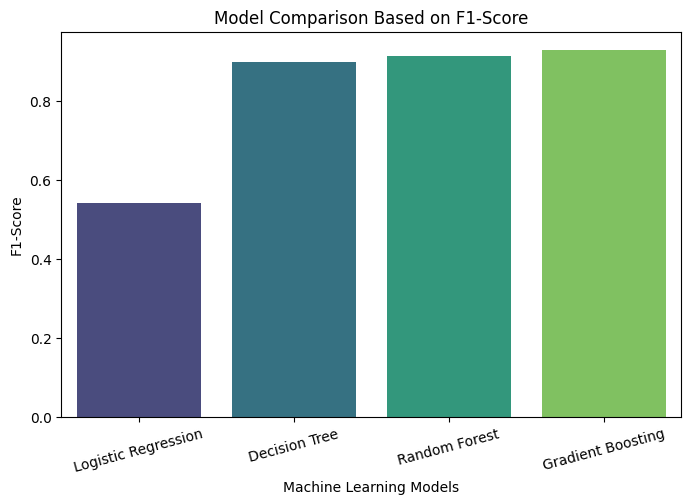

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-Score",
    palette="viridis"
)

plt.title("Model Comparison Based on F1-Score")
plt.xlabel("Machine Learning Models")
plt.ylabel("F1-Score")

plt.xticks(rotation=15)

plt.show()

## Step 9: Sort Models by F1-Score

Sort the models based on F1-Score to identify the best-performing model.

In [38]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.963804,0.973607,0.887701,0.928671
1,Random Forest,0.956707,0.978593,0.855615,0.912981
2,Decision Tree,0.946061,0.904891,0.890374,0.897574
3,Logistic Regression,0.792761,0.655303,0.462567,0.542320


## Step 10: Select the Best Model

Select the best-performing model based on the highest F1-Score.

In [39]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting


## Step 11: Retrain the Best Model

Retrain the best-performing model on the training dataset before saving it.

In [40]:
if best_model_name == "Logistic Regression":
    best_model = LogisticRegression(random_state=42)

elif best_model_name == "Decision Tree":
    best_model = DecisionTreeClassifier(random_state=42)

elif best_model_name == "Random Forest":
    best_model = RandomForestClassifier(random_state=42)

else:
    best_model = GradientBoostingClassifier(random_state=42)

# Train Best Model
best_model.fit(X_train, y_train)

print("Best model trained successfully.")

Best model trained successfully.


## Step 12: Generate Confusion Matrix

Visualize the classification performance of the best model using a confusion matrix.

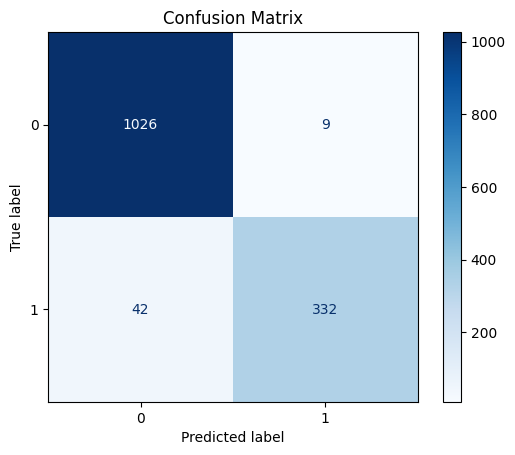

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

# Predictions
y_pred = best_model.predict(X_test)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

## Step 13: Generate Classification Report

Display Precision, Recall, F1-Score, and Support for each class.

In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.97      0.89      0.93       374

    accuracy                           0.96      1409
   macro avg       0.97      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



## Step 14: Save the Best Model

Save the trained model for deployment in the Streamlit application.

In [43]:
joblib.dump(
    best_model,
    "../models/customer_churn_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Key Findings

- Four machine learning algorithms were trained and compared.
- Gradient Boosting achieved the highest F1-Score and was selected as the final model.
- Model performance was evaluated using Accuracy, Precision, Recall, and F1-Score.
- A Confusion Matrix and Classification Report were generated to analyze classification performance.
- The trained model was saved for deployment in the Streamlit application.